# Environment

In [1]:
!nvidia-smi

Sun Sep 28 22:23:52 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 560.35.03              Driver Version: 560.35.03      CUDA Version: 12.6     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla P100-PCIE-16GB           Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P0             25W /  250W |       0MiB /  16384MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!lscpu

Architecture:             x86_64
  CPU op-mode(s):         32-bit, 64-bit
  Address sizes:          46 bits physical, 48 bits virtual
  Byte Order:             Little Endian
CPU(s):                   4
  On-line CPU(s) list:    0-3
Vendor ID:                GenuineIntel
  Model name:             Intel(R) Xeon(R) CPU @ 2.00GHz
    CPU family:           6
    Model:                85
    Thread(s) per core:   2
    Core(s) per socket:   2
    Socket(s):            1
    Stepping:             3
    BogoMIPS:             4000.28
    Flags:                fpu vme de pse tsc msr pae mce cx8 apic sep mtrr pge m
                          ca cmov pat pse36 clflush mmx fxsr sse sse2 ss ht sysc
                          all nx pdpe1gb rdtscp lm constant_tsc rep_good nopl xt
                          opology nonstop_tsc cpuid tsc_known_freq pni pclmulqdq
                           ssse3 fma cx16 pcid sse4_1 sse4_2 x2apic movbe popcnt
                           aes xsave avx f16c rdrand hypervisor 

In [3]:
!free -h

               total        used        free      shared  buff/cache   available
Mem:            31Gi       688Mi        23Gi       2.0Mi       7.1Gi        30Gi
Swap:             0B          0B          0B


In [4]:
!cat /etc/os-release

PRETTY_NAME="Ubuntu 22.04.4 LTS"
NAME="Ubuntu"
VERSION_ID="22.04"
VERSION="22.04.4 LTS (Jammy Jellyfish)"
VERSION_CODENAME=jammy
ID=ubuntu
ID_LIKE=debian
HOME_URL="https://www.ubuntu.com/"
SUPPORT_URL="https://help.ubuntu.com/"
BUG_REPORT_URL="https://bugs.launchpad.net/ubuntu/"
PRIVACY_POLICY_URL="https://www.ubuntu.com/legal/terms-and-policies/privacy-policy"
UBUNTU_CODENAME=jammy


In [5]:
!df -h

Filesystem                                                             Size  Used Avail Use% Mounted on
overlay                                                                7.9T  6.3T  1.7T  80% /
tmpfs                                                                   64M     0   64M   0% /dev
shm                                                                     14G     0   14G   0% /dev/shm
/dev/sdb1                                                              122G  4.7G  118G   4% /opt/bin
/dev/loop1                                                              20G  188K   20G   1% /kaggle/lib
192.168.7.2:/data/kagglesdsdata/datasets/3570200/6216738/dd332rhr5uuc   73T   55T   18T  76% /kaggle/input/tilda-400-64x64-patches
/dev/mapper/snap                                                       7.9T  6.3T  1.7T  80% /etc/hosts
tmpfs                                                                   16G     0   16G   0% /proc/acpi
tmpfs                                                  

In [6]:
import os
import random
import numpy as np
import pandas as pd
from glob import glob
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image
from collections import defaultdict
import time
import json

# Optional: Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Configurações de visualização
plt.style.use('ggplot')
%matplotlib inline

In [7]:
!pip freeze > requirements.txt

# Constants

In [8]:
# --- 1. CONFIGURATION ---
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
NUM_FOLDS = 5
BATCH_SIZE = 32
NUM_EPOCHS = 30
LEARNING_RATE = 1e-4

# Dedicated Test Set Split Ratio
TEST_RATIO = 0.10 

# Kaggle Environment Paths and Classes
ROOT_DIR = '/kaggle/working'
BASE_INPUT_PATH = '/kaggle/input/tilda-400-64x64-patches'
RANDOM_SEED = 42

# Get class names from directories
CLASS_NAMES = sorted([d for d in os.listdir(BASE_INPUT_PATH) if os.path.isdir(os.path.join(BASE_INPUT_PATH, d))])
CLASS_COUNT = len(CLASS_NAMES)

# Multi-class mapping (5 classes)
CLASS_LABELS = {
    'good': 0, 
    'hole': 1, 
    'objects': 2, 
    'oil spot': 3, 
    'thread error': 4
}
NUM_CLASSES = len(CLASS_LABELS)
MAJORITY_CLASS_ID = 0 # 'good'

# Patches are 64x64, but will be resized by transforms to 224x224 for ResNet50
IMG_SIZE = 224 

# Undersampling factors for the MAJORITY class ('good', class 0)
# UNDERSAMPLING_FACTORS = [1.0, 0.9, 0.75, 0.60, 0.45, 0.30, 0.15, 0.05]
UNDERSAMPLING_FACTORS = [0.05]

In [9]:
def set_seed(seed: int = 42) -> None:
    # Set a fixed value for the hash seed
    os.environ["PYTHONHASHSEED"] = str(seed)
    # Set seed for PyTorch
    torch.manual_seed(seed)
    # Set seed for CUDA (if using GPUs)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)  # For multi-GPU setups
    # Set seed for Python's random module
    random.seed(seed)
    # Set seed for NumPy
    np.random.seed(seed)
    #tf.random.set_seed(seed) # set random seed for TensorFlow
    print(f"Random seed set as {seed}\n")

set_seed(RANDOM_SEED)

Random seed set as 42



# Data Visualization

Random seed set as 42

Total images found: 25600

Original image count per class:
good            23170
objects           837
oil spot          636
thread error      620
hole              337
dtype: int64


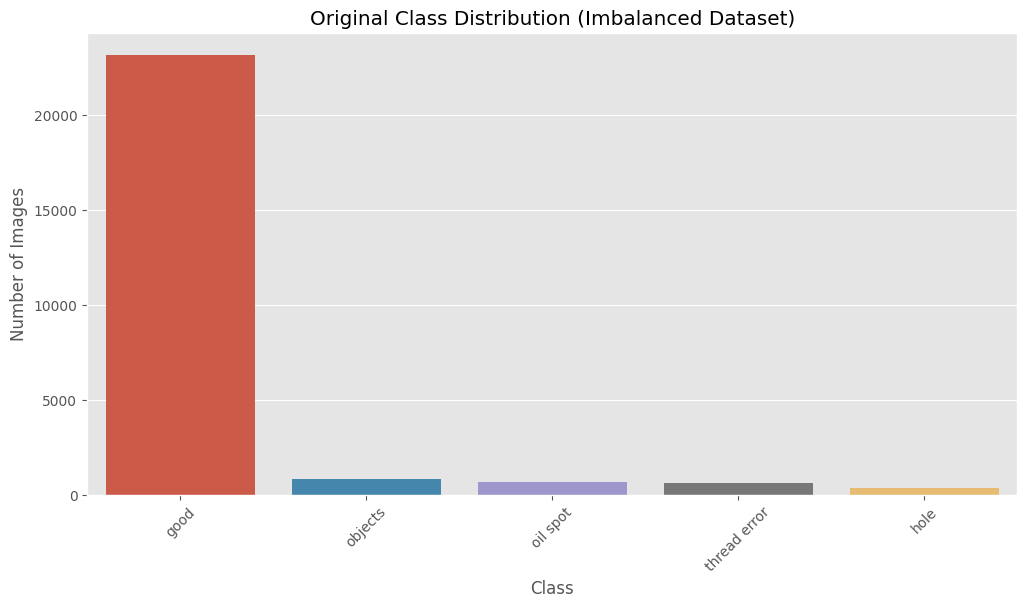

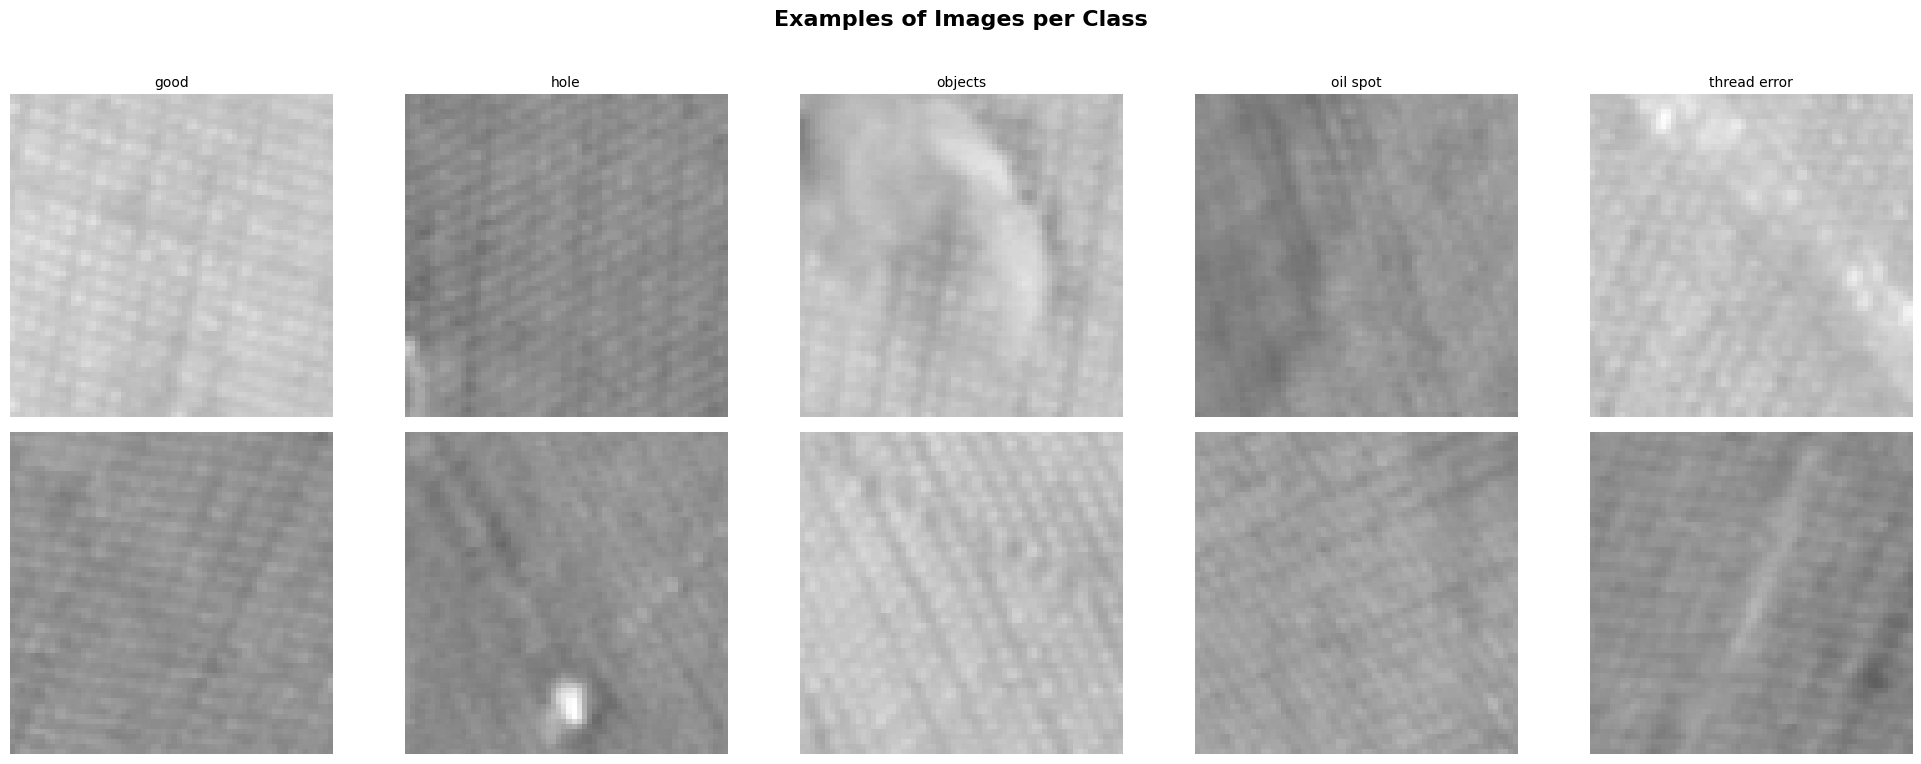

In [10]:
set_seed(RANDOM_SEED)

# Load all image paths and their respective labels
image_paths = []
labels = []
class_counts = {}

for class_name in CLASS_NAMES:
    class_dir = os.path.join(BASE_INPUT_PATH, class_name)
    paths = glob(os.path.join(class_dir, '*.png'))
    image_paths.extend(paths)
    labels.extend([class_name] * len(paths))
    class_counts[class_name] = len(paths)

df = pd.DataFrame({
    'image_path': image_paths,
    'label': labels
})

print(f"Total images found: {len(df)}")
print("\nOriginal image count per class:")
print(pd.Series(class_counts).sort_values(ascending=False))

# Plot the original distribution
plt.figure(figsize=(12, 6))
sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()), order=pd.Series(class_counts).sort_values(ascending=False).index)
plt.title('Original Class Distribution (Imbalanced Dataset)')
plt.ylabel('Number of Images')
plt.xlabel('Class')
plt.xticks(rotation=45)
plt.show()

fig, axes = plt.subplots(nrows=2, ncols=CLASS_COUNT, figsize=(CLASS_COUNT * 4, 8)) # Adjust figsize as needed
fig.suptitle('Examples of Images per Class', fontsize=16, weight='bold')

for i, class_name in enumerate(CLASS_NAMES):
    # Sample 2 image paths for the current class
    sample_paths = df[df['label'] == class_name]['image_path'].sample(2).values
    
    # Display the first image in the first row, 'i'-th column
    img1 = Image.open(sample_paths[0])
    axes[0, i].imshow(img1)
    axes[0, i].set_title(class_name, fontsize=10)
    axes[0, i].axis('off')
    # Display the second image in the second row, 'i'-th column
    img2 = Image.open(sample_paths[1])
    axes[1, i].imshow(img2)
    axes[1, i].axis('off')

plt.subplots_adjust(hspace=0.4)
plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()

# Data Utilities

In [11]:
set_seed(RANDOM_SEED)

# --- 2. DATA UTILITIES ---

def load_real_data(base_path, class_names):
    """
    Scans the actual Kaggle file system to collect patch paths, image IDs, 
    and multi-class labels (0-4) for classification, and multi-class labels for stratification.
    
    Returns:
    - patch_df: DataFrame of (filepath, image_id, label) for all patches (labels 0-4)
    - image_ids_in_pool: List of unique image IDs (All unique IDs found)
    - image_id_labels_for_stratification: List of multi-class labels (0-4)
    """
    all_patch_data = []
    # Tracks ALL patch labels associated with an image ID (used for multi-class stratification)
    image_id_patch_labels = defaultdict(list) 
    
    # Use the 5-class labels defined in CLASS_LABELS
    class_to_label = CLASS_LABELS
    
    for class_name in class_names:
        current_label = class_to_label[class_name]
        
        # Use glob to find all patches in the class folder
        patch_paths = glob(os.path.join(base_path, class_name, "*.png"))
        
        for path in patch_paths:
            fname = os.path.basename(path)
            
            # Extract Image ID based on the structure: [ID]_patch[X-Y].png
            if "_patch" in fname:
                # Split by '_patch' and take the first part
                image_id = fname.split("_patch")[0] 
            else:
                # Fallback: if 'patch' is not in the name, use the file name base (excluding extension)
                image_id = fname.split(".")[0] 
            
            # 1. Collect patch data (multi-class label 0-4)
            all_patch_data.append({
                'filepath': path,
                'image_id': image_id,
                'label': current_label
            })
            
            # 2. Track multi-class label for stratification (0-4)
            image_id_patch_labels[image_id].append(current_label)

    patch_df = pd.DataFrame(all_patch_data)
    
    # 3. Prepare stratification data (unique image IDs and their primary MULTI-CLASS label: 0-4)
    # This section is kept to correctly report the image stratification counts and create the labels for the K-Fold split.
    image_ids_in_pool = sorted(patch_df['image_id'].unique())
    
    image_id_labels_for_stratification_list = []
    for img_id in image_ids_in_pool:
        label_list = image_id_patch_labels[img_id]
        
        # Assign the image ID the lowest numbered defect class present, or 'good' (0) if none.
        if any(label != MAJORITY_CLASS_ID for label in label_list):
            defect_labels = [label for label in label_list if label != MAJORITY_CLASS_ID]
            image_id_labels_for_stratification_list.append(min(defect_labels)) 
        else:
            image_id_labels_for_stratification_list.append(MAJORITY_CLASS_ID)
            
    image_id_labels_for_stratification = np.array(image_id_labels_for_stratification_list)
    
    total_patches = len(patch_df)
    total_good = np.sum(patch_df['label'] == MAJORITY_CLASS_ID)
    
    # Prepare data for multi-class printout
    print_counts = {label: np.sum(image_id_labels_for_stratification == label) for label in range(NUM_CLASSES)}
    reverse_class_labels = {v: k for k, v in CLASS_LABELS.items()}
    
    count_strings = []
    for i in range(NUM_CLASSES):
        class_name = reverse_class_labels.get(i, f'Unknown({i})')
        count = print_counts.get(i, 0)
        count_strings.append(f"{class_name}({i})={count}")
        
    print(f"Real Data Loaded: {len(image_ids_in_pool)} unique Image IDs and {total_patches} total patches.")
    print(f"Initial Patch Split (Multi-class): Good (0)={total_good}, Defects (1-4)={total_patches - total_good}.")
    print(f"Image Stratification Split (Multi-class): {', '.join(count_strings)}")
    
    return patch_df, np.array(image_ids_in_pool), image_id_labels_for_stratification

Random seed set as 42



# Transforms & Dataset Class

In [12]:
set_seed(RANDOM_SEED)

# --- DATA TRANSFORMS ---
# Training transformations including augmentation
transform_train = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomAffine(
        degrees=20,
        translate=(0.1, 0.1),
        scale=(0.9, 1.1),
        fill=0  # fill missing pixels with black (grayscale)
    ),
    transforms.ColorJitter(
        hue=0.015,
        saturation=0.7,
        brightness=0.4
    ),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]),
    transforms.RandomErasing(p=0.4, scale=(0.02, 0.2), ratio=(0.3, 3.3), value='random')
])

# Evaluation transformations (no augmentation)
transform_eval = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])


class TextileDataset(Dataset):
    """
    A PyTorch Dataset class. Loads images using PIL and applies the provided transform.
    """
    def __init__(self, filepaths, labels, transform=None):
        self.filepaths = filepaths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.filepaths)

    def __getitem__(self, idx):
        path = self.filepaths[idx]
        label = self.labels[idx]

        try:
            # Load image (we load as RGB first, and the transform_train/eval
            # will convert it to Grayscale (1 channel) later)
            image = Image.open(path).convert('RGB')
        except Exception as e:
            # Handle real-world errors during file access (e.g., corrupt files)
            print(f"Error loading image {path}: {e}. Returning zero tensor.")
            image = torch.zeros(1, IMG_SIZE, IMG_SIZE) 
        # ---------------------------------------

        if self.transform:
            image = self.transform(image)
        
        return image, torch.tensor(label, dtype=torch.long)

Random seed set as 42



# Model

In [13]:
set_seed(RANDOM_SEED)

# --- 3. MODEL AND TRAINING UTILITIES ---

def get_resnet50(num_classes):
    """
    Loads ResNet50 with V2 weights, adapts the first convolutional layer 
    for single-channel (grayscale) input, and modifies the final classification layer.
    """
    # Load with V2 weights
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
    
    # CRITICAL CHANGE: Adapt conv1 for 1 channel (Grayscale)
    model.conv1 = nn.Conv2d(
        1, # Input channels changed from 3 to 1
        64, 
        kernel_size=7, 
        stride=2, 
        padding=3, 
        bias=False
    )
    
    # Replace the final classification layer, now set to NUM_CLASSES (5)
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, num_classes)
    
    return model.to(DEVICE)

Random seed set as 42



# Training Utilities

In [14]:
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs):
    """Training and validation loop for one fold, returning training time."""
    
    start_time = time.time()
    
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        
        # Training Phase
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * inputs.size(0)
            
        # Validation Phase (at the end of each epoch)
        model.eval()
        all_preds = []
        all_labels = []
        
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        epoch_loss = running_loss / len(train_loader.dataset)
        val_acc = accuracy_score(all_labels, all_preds)
        
        # Calculate both weighted and macro F1 scores
        val_f1_weighted = f1_score(all_labels, all_preds, average='weighted')
        val_f1_macro = f1_score(all_labels, all_preds, average='macro')
        
        print(f"  Epoch {epoch+1}/{num_epochs}: Train Loss={epoch_loss:.4f} | Val Acc={val_acc:.4f} | Val F1 (W)={val_f1_weighted:.4f} | Val F1 (M)={val_f1_macro:.4f}")
    
    end_time = time.time()
    training_time = end_time - start_time
    
    # Final evaluation metrics on the validation set for the fold
    cm = confusion_matrix(all_labels, all_preds)
    
    return val_acc, val_f1_weighted, val_f1_macro, cm, training_time

# Main Experiment Loop

In [15]:
set_seed(RANDOM_SEED)

# --- 4. MAIN EXPERIMENT LOOP ---

def run_experiment():
    """Runs the full cross-validation and undersampling experiment."""
    
    # 1. Load Data (gets patches and image IDs for stratification)
    # image_ids and image_id_labels are for all 400 original images.
    patch_df, image_ids, image_id_labels = load_real_data(BASE_INPUT_PATH, list(CLASS_LABELS.keys()))
    
    # 2. STEP 1: Initial Image ID Split (NON-STRATIFIED TEST/TRAINVAL separation)
    
    all_image_ids_full = image_ids
    num_total_images = len(all_image_ids_full)
    num_test_images = max(1, int(num_total_images * TEST_RATIO))
    
    # --- NON-STRATIFIED SPLIT ---
    # Shuffle all image IDs randomly to select the test set (10% of image IDs)
    np.random.seed(RANDOM_SEED) # Ensure reproducibility for this initial, random split
    np.random.shuffle(all_image_ids_full)
    
    test_image_ids = all_image_ids_full[:num_test_images]
    trainval_pool_image_ids = all_image_ids_full[num_test_images:]
    # ----------------------------

    print(f"\n--- Initial Data Split (Non-Stratified) ---")
    print(f"Total Image IDs: {num_total_images}")
    print(f"Dedicated Test Set Split ({TEST_RATIO*100:.0f}%): {len(test_image_ids)} image IDs.")
    print(f"K-Fold Train/Validation Pool: {len(trainval_pool_image_ids)} image IDs.")

    # Collect the patches for the dedicated Test Set
    test_patches_final_df = patch_df[patch_df['image_id'].isin(test_image_ids)]
    X_test_final = test_patches_final_df['filepath'].values
    y_test_final = test_patches_final_df['label'].values
    
    final_test_dataset = TextileDataset(X_test_final, y_test_final, transform=transform_eval)
    final_test_loader = DataLoader(final_test_dataset, batch_size=BATCH_SIZE, shuffle=False)
    print(f"Dedicated Test Set Ready with {len(y_test_final)} patches for final evaluation.")

    # --- START OF IMAGE-ID STRATIFICATION SETUP (Reverted to correct method) ---
    
    # Prepare stratification labels for the remaining Train/Validation Pool
    # image_id_labels contains the multi-class (0-4) label for *all* image IDs (Test + TrainVal)
    image_id_to_multi_class_label = {img_id: label for img_id, label in zip(image_ids, image_id_labels)}
    
    # Get the stratification labels specifically for the images in the TrainVal pool
    trainval_pool_labels_for_stratification = np.array([
        image_id_to_multi_class_label[img_id] for img_id in trainval_pool_image_ids
    ])

    # 3. STEP 2: K-Fold Cross-Validation on the Train/Validation Pool (STRATIFIED on IMAGE IDs)
    # This split is based on Image IDs to prevent leakage, stratified by image-level defect class.
    skf = StratifiedKFold(n_splits=NUM_FOLDS, shuffle=True, random_state=RANDOM_SEED)
    
    all_results = []

    print("\n--- Starting Undersampling Experiment (Stratified K-Fold on IMAGE IDs) ---")
    
    # --- END OF IMAGE-ID STRATIFICATION SETUP ---

    for factor in UNDERSAMPLING_FACTORS:
        print(f"\n[Factor: {factor*100:.0f}% of Majority Class Patches in Training Set]")
        
        fold_results = []
        final_model_for_test = None # Will store the model from the last fold for final test

        # K-Fold Iteration on Image IDs in the Train/Validation Pool
        # `train_indices` and `val_indices` are indices of the `trainval_pool_image_ids` array
        for fold, (train_indices, val_indices) in enumerate(skf.split(trainval_pool_image_ids, trainval_pool_labels_for_stratification)):
            print(f"  > Running Fold {fold+1}/{NUM_FOLDS} (Splitting by Image ID)...")
            
            # --- Separate Train and Validation Image IDs ---
            current_train_image_ids = trainval_pool_image_ids[train_indices]
            current_val_image_ids = trainval_pool_image_ids[val_indices]

            # --- Collect Patches for the current split ---
            # NOTE: We use the full patch_df here, filtering only by the chosen image IDs
            train_patches_all = patch_df[patch_df['image_id'].isin(current_train_image_ids)]
            val_patches_all = patch_df[patch_df['image_id'].isin(current_val_image_ids)]

            # Separate majority ('good', class 0) and minority (classes 1-4) patches in the training set
            train_majority_patches = train_patches_all[train_patches_all['label'] == MAJORITY_CLASS_ID]
            train_minority_patches = train_patches_all[train_patches_all['label'] != MAJORITY_CLASS_ID]
            
            # --- Apply Undersampling to the Majority Patches in the Training Set ONLY ---
            
            original_majority_size = len(train_majority_patches)
            target_majority_size = int(original_majority_size * factor)
            
            if target_majority_size < original_majority_size and original_majority_size > 0:
                train_majority_sampled = train_majority_patches.sample(
                    n=target_majority_size, 
                    replace=False, 
                    random_state=RANDOM_SEED
                )
                
                train_sampled_df = pd.concat([train_majority_sampled, train_minority_patches])
            else:
                train_sampled_df = train_patches_all
            
            # Extract final sampled data arrays
            X_train_sampled = train_sampled_df['filepath'].values
            y_train_sampled = train_sampled_df['label'].values
            
            X_val = val_patches_all['filepath'].values
            y_val = val_patches_all['label'].values
            
            
            print(f"    Train Set Size (Undersampled): Good (0)={np.sum(y_train_sampled == MAJORITY_CLASS_ID)}, Defects (1-4)={np.sum(y_train_sampled != MAJORITY_CLASS_ID)}")
            
            # --- Setup DataLoaders ---
            train_dataset = TextileDataset(X_train_sampled, y_train_sampled, transform=transform_train)
            val_dataset = TextileDataset(X_val, y_val, transform=transform_eval)
            
            train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
            val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
            
            # --- Initialize Model, Loss, Optimizer ---
            model = get_resnet50(num_classes=NUM_CLASSES) 
            criterion = nn.CrossEntropyLoss()
            optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE) 
            
            # --- Train and Evaluate ---
            # Now captures training time and returns both F1 metrics
            val_acc, val_f1_weighted, val_f1_macro, cm, train_time = train_model(
                model, 
                train_loader, 
                val_loader, 
                criterion, 
                optimizer, 
                NUM_EPOCHS
            )
            
            # Store the last trained model to use for the final dedicated test
            if fold == NUM_FOLDS - 1:
                 final_model_for_test = model 
            
            fold_results.append({
                'fold': fold + 1,
                'accuracy': float(val_acc), # Ensure float
                'f1_weighted': float(val_f1_weighted), # Ensure float
                'f1_macro': float(val_f1_macro), # Ensure float
                'confusion_matrix': cm.tolist(),
                'train_majority_size': int(np.sum(y_train_sampled == MAJORITY_CLASS_ID)),
                'train_minority_size': int(np.sum(y_train_sampled != MAJORITY_CLASS_ID)),
                'train_time_sec': float(train_time) # Ensure float
            })
            
            print(f"    Fold {fold+1} Results: Val Acc={val_acc:.4f}, Val F1 (W)={val_f1_weighted:.4f}, Val F1 (M)={val_f1_macro:.4f}, Train Time={train_time:.1f}s")

        # --- Aggregate Results for this Factor ---
        # --- Fix: Cast NumPy floats to Python float before saving ---
        avg_acc = float(np.mean([r['accuracy'] for r in fold_results]))
        avg_f1_weighted = float(np.mean([r['f1_weighted'] for r in fold_results]))
        avg_f1_macro = float(np.mean([r['f1_macro'] for r in fold_results]))
        avg_time = float(np.mean([r['train_time_sec'] for r in fold_results]))
        
        # --- FINAL DEDICATED TEST EVALUATION ---
        print("\n  >>> Running Final Evaluation on DEDICATED TEST SET (Unseen Data)...")
        
        if final_model_for_test:
            final_model_for_test.eval()
            all_preds_final = []
            all_labels_final = []
            
            with torch.no_grad():
                for inputs, labels in final_test_loader:
                    inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
                    outputs = final_model_for_test(inputs)
                    _, preds = torch.max(outputs, 1)
                    
                    all_preds_final.extend(preds.cpu().numpy())
                    all_labels_final.extend(labels.cpu().numpy())
                    
            test_acc_final = accuracy_score(all_labels_final, all_preds_final)
            test_f1_weighted_final = f1_score(all_labels_final, all_preds_final, average='weighted')
            test_f1_macro_final = f1_score(all_labels_final, all_preds_final, average='macro')
        else:
            test_acc_final, test_f1_weighted_final, test_f1_macro_final = np.nan, np.nan, np.nan
            
        # Ensure final test results are also cast to standard Python floats
        test_acc_final_py = float(test_acc_final) if not np.isnan(test_acc_final) else None
        test_f1_weighted_final_py = float(test_f1_weighted_final) if not np.isnan(test_f1_weighted_final) else None
        test_f1_macro_final_py = float(test_f1_macro_final) if not np.isnan(test_f1_macro_final) else None
        
        print(f"  DEDICATED TEST SET RESULTS: Acc={test_acc_final:.4f}, F1 (W)={test_f1_weighted_final:.4f}, F1 (M)={test_f1_macro_final:.4f}")
        
        current_factor_results = {
            'factor': factor,
            'avg_accuracy': avg_acc,
            'avg_f1_weighted': avg_f1_weighted,
            'avg_f1_macro': avg_f1_macro,
            'avg_train_time': avg_time, 
            'final_test_acc': test_acc_final_py,
            'final_test_f1_weighted': test_f1_weighted_final_py,
            'final_test_f1_macro': test_f1_macro_final_py,
            'fold_details': fold_results
        }
        
        # --- Save results to JSON file ---
        # Filename example: results_factor_100.json, results_factor_5.json
        filename = os.path.join(ROOT_DIR, f"results_factor_{factor*100:.0f}.json")
        try:
            # This should now work as all NumPy types have been converted
            with open(filename, 'w') as f:
                json.dump(current_factor_results, f, indent=4)
            print(f"  Results saved to: {filename}")
        except Exception as e:
            # Kept for unexpected errors, but the int64 issue should be solved
            print(f"  Error saving results to JSON: {e}")
        # -----------------------------------
        
        # Append to the list
        all_results.append(current_factor_results) 
        
        print(f"\n[Factor: {factor*100:.0f}%] SUMMARY: Avg. Val F1 (W)={avg_f1_weighted:.4f} | Avg. Val F1 (M)={avg_f1_macro:.4f} | Avg. Time={avg_time:.1f}s | Final Test F1 (W)={test_f1_weighted_final_py:.4f} | Final Test F1 (M)={test_f1_macro_final_py:.4f}")


    # 5. Print Final Summary
    print("\n--- FINAL EXPERIMENT SUMMARY ---")
    summary_df = pd.DataFrame([
        {
            'Factor (%)': f['factor'] * 100, 
            'Avg Validation Accuracy': f['avg_accuracy'], 
            'Avg Validation F1 (W)': f['avg_f1_weighted'],
            'Avg Validation F1 (M)': f['avg_f1_macro'],
            'Avg Train Time (s)': f['avg_train_time'],
            'Final Test Accuracy': f['final_test_acc'],
            'Final Test F1 (W)': f['final_test_f1_weighted'],
            'Final Test F1 (M)': f['final_test_f1_macro']
        } for f in all_results
    ])
    print(summary_df.sort_values(by='Factor (%)', ascending=False).to_markdown(index=False))

Random seed set as 42



In [16]:
set_seed(RANDOM_SEED)

run_experiment()

Random seed set as 42

Real Data Loaded: 400 unique Image IDs and 25600 total patches.
Initial Patch Split (Multi-class): Good (0)=23170, Defects (1-4)=2430.
Image Stratification Split (Multi-class): good(0)=0, hole(1)=101, objects(2)=100, oil spot(3)=99, thread error(4)=100

--- Initial Data Split (Non-Stratified) ---
Total Image IDs: 400
Dedicated Test Set Split (10%): 40 image IDs.
K-Fold Train/Validation Pool: 360 image IDs.
Dedicated Test Set Ready with 2560 patches for final evaluation.

--- Starting Undersampling Experiment (Stratified K-Fold on IMAGE IDs) ---

[Factor: 5% of Majority Class Patches in Training Set]
  > Running Fold 1/5 (Splitting by Image ID)...
    Train Set Size (Undersampled): Good (0)=833, Defects (1-4)=1763


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 220MB/s]


  Epoch 1/30: Train Loss=1.5121 | Val Acc=0.6120 | Val F1 (W)=0.7095 | Val F1 (M)=0.2412
  Epoch 2/30: Train Loss=1.3084 | Val Acc=0.8431 | Val F1 (W)=0.8680 | Val F1 (M)=0.4633
  Epoch 3/30: Train Loss=1.1390 | Val Acc=0.8813 | Val F1 (W)=0.8928 | Val F1 (M)=0.5106
  Epoch 4/30: Train Loss=1.0713 | Val Acc=0.7836 | Val F1 (W)=0.8386 | Val F1 (M)=0.4816
  Epoch 5/30: Train Loss=0.9842 | Val Acc=0.9000 | Val F1 (W)=0.9086 | Val F1 (M)=0.5682
  Epoch 6/30: Train Loss=0.9130 | Val Acc=0.8563 | Val F1 (W)=0.8812 | Val F1 (M)=0.5293
  Epoch 7/30: Train Loss=0.8682 | Val Acc=0.7183 | Val F1 (W)=0.7943 | Val F1 (M)=0.4837
  Epoch 8/30: Train Loss=0.8049 | Val Acc=0.8711 | Val F1 (W)=0.8953 | Val F1 (M)=0.5675
  Epoch 9/30: Train Loss=0.7466 | Val Acc=0.8312 | Val F1 (W)=0.8674 | Val F1 (M)=0.5344
  Epoch 10/30: Train Loss=0.7152 | Val Acc=0.8874 | Val F1 (W)=0.9037 | Val F1 (M)=0.6173
  Epoch 11/30: Train Loss=0.6743 | Val Acc=0.9045 | Val F1 (W)=0.9173 | Val F1 (M)=0.6422
  Epoch 12/30: Trai